In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
train = pd.read_csv("titanic_train.csv")
train.head()

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False);

In [ ]:
sns.set_style("whitegrid")

In [ ]:
sns.countplot(x="Survived", hue="Pclass", data=train)

In [ ]:
sns.displot(train['Age'].dropna())

In [ ]:
train.info

In [ ]:
sns.countplot(x=train['SibSp'], data=train)

In [ ]:
train['Fare'].hist(bins=40)

In [ ]:
sns.boxplot(x='Pclass',y='Age', data=train)

In [ ]:
def impute_age(cols):
    Age= cols[0]
    Pclass=cols[1]
    if pd.isnull(Age):
        if Pclass==1:
            return 37
        elif Pclass ==2:
            return 29
        else:
            return 24
    else:
        return Age    
    
        

In [ ]:
train['Age']= train[['Age','Pclass']].apply(impute_age,axis=1)

<Axes: >

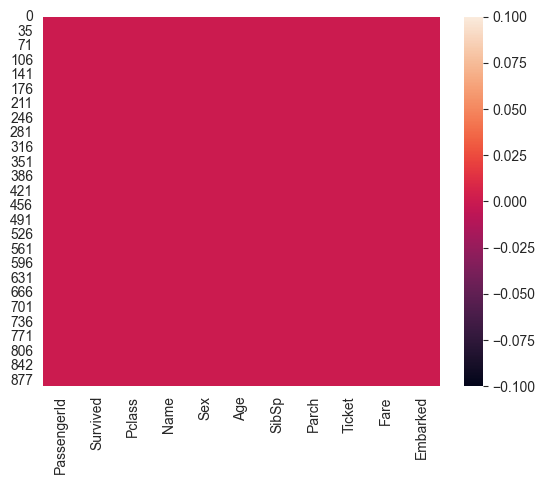

In [40]:
sns.heatmap(train.isnull())

In [ ]:
train.drop('Cabin', axis=1, inplace= True)

In [37]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [39]:
train.dropna(inplace=True)

In [52]:
sex =pd.get_dummies(train['Sex'], drop_first=True,dtype=int)

In [53]:
embark=pd.get_dummies(train['Embarked'], drop_first=True,dtype=int)

In [65]:
train= pd.concat([train,sex,embark],axis=1)


In [66]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


In [63]:
train.drop(['Sex','Embarked','Name','Ticket','male','Q','S'],axis=1,inplace=True)

In [67]:
train.drop(['PassengerId'],axis=1,inplace=True)

In [68]:
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [69]:
X=train.drop('Survived',axis=1)
Y=train['Survived']

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,Y, train_size=0.3, random_state= 101)

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
logModel= LogisticRegression()

In [75]:
logModel.fit(X_train,y_train)

c:\Users\visha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [76]:
prediction=logModel.predict(X_test)

In [77]:
from sklearn.metrics import classification_report

In [78]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       384
           1       0.76      0.69      0.72       239

    accuracy                           0.80       623
   macro avg       0.79      0.78      0.78       623
weighted avg       0.79      0.80      0.79       623



In [79]:
from sklearn.metrics import confusion_matrix

In [80]:
confusion_matrix(y_test,prediction)

array([[331,  53],
       [ 74, 165]], dtype=int64)